## Path configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [ ]:
import pickle
import numpy as np
import pandas as pd

# utils
from src.config.loader import *
from src.data.datasets import *
from src.data.preprocessing import *
from src.evaluation.metrics import *
from src.visualization.viz import *

# tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import balanced_accuracy_score, f1_score, recall_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder


# models
from sklearn.ensemble import RandomForestClassifier
import torch
from models.baselines.mlp import MLPClassifier_Extended
from torch.utils.data import TensorDataset, DataLoader

## Data loading

In [3]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]
marisma_pkl = cfg["data"]["MARISMa_REDUCED_PKL"]

In [4]:
driams = load_pkl(driams_pkl)
marisma = load_pkl(marisma_pkl)

In [5]:
data, label, meta = driams["data"], driams["label"], pd.DataFrame.from_records(list(driams["meta"]))
data_marisma, label_marisma, meta_marisma = marisma["data"], marisma["label"], pd.DataFrame.from_records(list(marisma["meta"]))

In [6]:
meta_marisma = meta_marisma.copy()

meta_marisma.insert(
    loc=0,
    column="hospital",
    value="MARISMA"
)

In [7]:
# Apply normalization: scale each spectrum to [0, 1]
X_min = data.min(axis=1, keepdims=True)
X_max = data.max(axis=1, keepdims=True)
data_norm = (data - X_min) / (X_max - X_min + 1e-8)

In [8]:
# Apply normalization: scale each spectrum to [0, 1]
X_min_marisma = data_marisma.min(axis=1, keepdims=True)
X_max_marisma = data_marisma.max(axis=1, keepdims=True)
data_norm_marisma = (data_marisma - X_min_marisma) / (X_max_marisma - X_min_marisma + 1e-8)

In [9]:
# Filter the data by hospital
filtered_data = {}
for hosp in meta["hospital"].unique():
    idx = np.where(meta["hospital"].values == hosp)[0]
    filtered_data[hosp] = {
        "data": data_norm[idx],
        "label": label[idx],
        "meta": meta.iloc[idx]
    }

In [10]:
# Declare the datasets
dataA, labelA, metaA = filtered_data["DRIAMS_A"]["data"], filtered_data["DRIAMS_A"]["label"], filtered_data["DRIAMS_A"]["meta"]
dataD, labelD, metaD = filtered_data["DRIAMS_D"]["data"], filtered_data["DRIAMS_D"]["label"], filtered_data["DRIAMS_D"]["meta"]

## Original space (train on DRIAMS-A + MARISMa, test on D)

In [11]:
data_all = np.vstack([dataA, dataD, data_norm_marisma])
label_all= np.concatenate([labelA, labelD, label_marisma])
meta_all = pd.concat([metaA, metaD, meta_marisma], ignore_index=True)

In [12]:
data_train = np.vstack([dataA, data_norm_marisma])
label_train = np.concatenate([labelA, label_marisma])
meta_train = pd.concat([metaA, meta_marisma], ignore_index=True)
data_test, label_test, meta_test = dataD, labelD, metaD

In [13]:
le = LabelEncoder()
y_encoded = le.fit_transform(label_train)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    data_train,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    shuffle=True,
    random_state=42
)

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,      
    stratify=y_train,
    random_state=42
)

In [16]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

In [17]:
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)

In [18]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

#### Train

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [20]:
mlp = MLPClassifier_Extended(X_train.shape[1], len(np.unique(label_all)), epochs=50, lr=1e-4, patience=20)
mlp.trainloop(train_loader, val_loader, device)

Epoch 10/50 | Train Loss: 0.0009736517193768799 | Validation Loss: 0.014979882620578932
Epoch 20/50 | Train Loss: 0.00043114989626656875 | Validation Loss: 0.01836573646241959
Early stopping at epoch 22


In [22]:
def plot_training_curves(train_loss, val_loss, title="MLP training"):
    epochs = range(1, len(train_loss) + 1)

    plt.figure()
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, val_loss, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

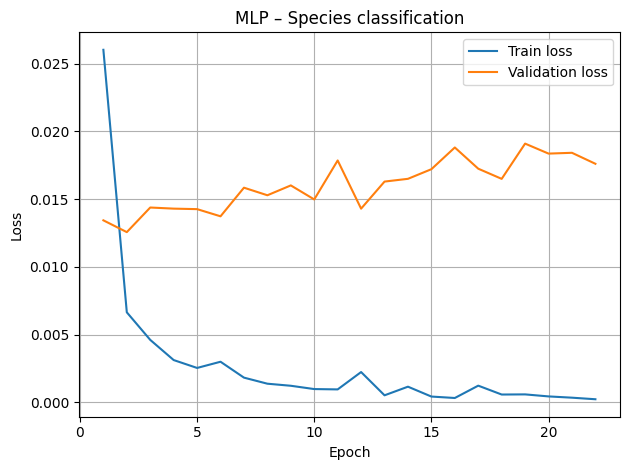

In [23]:
plot_training_curves(
    mlp.loss_during_training,
    mlp.val_loss_during_training,
    title="MLP – Species classification"
)

#### Test

In [24]:
def make_test_loader(X, y, batch_size=256):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(X_t, y_t)
    return DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [25]:
yD_encoded = le.transform(labelD)
test_loader_AM = make_test_loader(X_test, y_test)
test_loader_D = make_test_loader(dataD, yD_encoded)

In [26]:
def metrics_report_mlp(dataloader, model, domain_name, device="cpu", class_names=None):
    model.eval()
    model.to(device)

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)

            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            y_true.append(y.numpy())
            y_pred.append(preds.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    recall_macro = recall_score(y_true, y_pred, average="macro")

    cm = confusion_matrix(y_true, y_pred)

    specificity = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity.append(tn / (tn + fp))
    spec_macro = np.mean(specificity)

    return {
        "Domain": domain_name,
        "Labels": np.unique(y_true) if class_names is None else class_names,
        "Balanced_Accuracy": bal_acc,
        "F1_Macro": f1_macro,
        "Recall_Macro": recall_macro,
        "Specificity_Macro": spec_macro,
        "Confusion Matrix": cm
    }


===== Metrics =====
Domain: DRIAMS-A + MARISMA
Balanced Accuracy: 0.9963
F1 Macro: 0.9970
Recall Macro: 0.9963
Specificity Macro: 0.9996



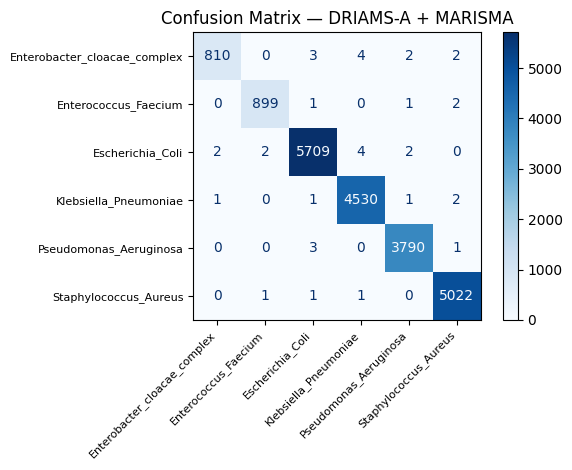


===== Metrics =====
Domain: DRIAMS-D
Balanced Accuracy: 0.9108
F1 Macro: 0.8720
Recall Macro: 0.9108
Specificity Macro: 0.9792



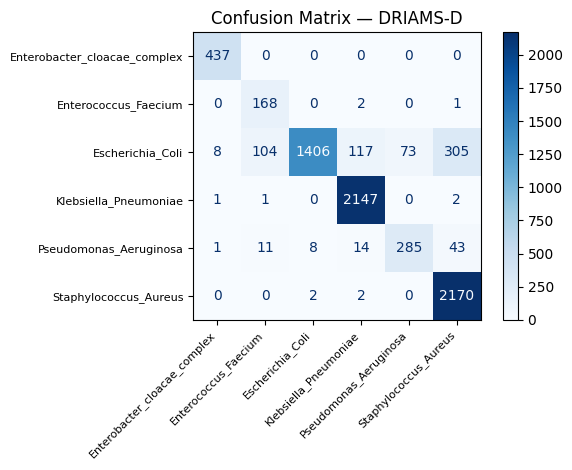

In [27]:
metricsAM = metrics_report_mlp(test_loader_AM, mlp, "DRIAMS-A + MARISMA", class_names=le.classes_)
metricsD = metrics_report_mlp(test_loader_D, mlp, "DRIAMS-D", class_names=le.classes_)

print_metrics(metricsAM)
print_metrics(metricsD)

## After domain alignment

#### Utils

In [ ]:
import torch
from models.deep.MultiVAEPrior import MultiVAE_Bernoulli_SpeciesPrior_Extended

In [30]:
def load_model(model, path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

def encode_latent(model, X, device, batch_size=256):
    model.eval()
    Z = []

    X_tensor = torch.tensor(X, dtype=torch.float32)

    loader = torch.utils.data.DataLoader(
        X_tensor,
        batch_size=batch_size,
        shuffle=False
    )

    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            mu, _ = model.encoder(x)
            Z.append(mu.cpu().numpy())

    return np.vstack(Z)

#### Load and train

In [31]:
le = LabelEncoder()
y_all_enc = le.fit_transform(label_all)
class_names = le.classes_

In [32]:
vae_path = "/export/usuarios01/agnavarr/MALDIAlign/experiments/results/vae_multidecoder_prior/20260202_093843/model.pth"

backbone = MultiVAE_Bernoulli_SpeciesPrior_Extended(
    input_dim=dataA.shape[1],
    latent_dim=64,
    num_domains=2,
    n_species=len(np.unique(y_all_enc))
)

vae = load_model(backbone, vae_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [39]:
Z_all = encode_latent(
    model=vae,
    X=data_all,
    device=device
)

print("Latent space shape:", Z_all.shape)

# Get latent representations
mask_A = meta_all["hospital"] == "DRIAMS_A"
mask_D = meta_all["hospital"] == "DRIAMS_D"
mask_M = meta_all["hospital"] == "MARISMA"

Z_A = Z_all[mask_A]
Z_D = Z_all[mask_D]
Z_M = Z_all[mask_M]

y_A = y_all_enc[mask_A]
y_D = y_all_enc[mask_D]
y_M = y_all_enc[mask_M]

print(f"Z_A: {Z_A.shape}")
print(f"Z_D: {Z_D.shape}")
print(f"Z_M: {Z_M.shape}")

# Define train and test
Z_train, y_train_z = np.vstack([Z_A, Z_M]), np.concatenate([y_A, y_M])
Z_test_D, y_test_D = Z_D, y_D

Latent space shape: (111290, 64)
Z_A: (27810, 64)
Z_D: (7308, 64)
Z_M: (76172, 64)


In [40]:
Z_train, Z_test, y_train_z, y_test_z = train_test_split(
    Z_train,
    y_train_z,
    test_size=0.2,
    stratify=y_train_z,
    random_state=42
)

Z_train, Z_val, y_train_z, y_val_z = train_test_split(
    Z_train,
    y_train_z,
    test_size=0.1,
    stratify=y_train_z,
    random_state=42
)

In [46]:
def make_loader(X, y, batch_size=256, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(
        TensorDataset(X_t, y_t),
        batch_size=batch_size,
        shuffle=shuffle
    )

train_loader = make_loader(Z_train, y_train_z, shuffle=True)
val_loader   = make_loader(Z_val, y_val_z, shuffle=False)

test_loader_AM = make_loader(Z_test, y_test_z)
test_loader_D = make_loader(Z_D, y_D)

In [44]:
mlp = MLPClassifier_Extended(
    input_dim=Z_train.shape[1],
    n_species=len(class_names),
    epochs=50,
    lr=1e-3,
    patience=10
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mlp.trainloop(train_loader, val_loader, device)

Epoch 10/50 | Train Loss: 0.0009433651470745635 | Validation Loss: 0.006049855373875647
Early stopping at epoch 17


#### Test


===== Metrics =====
Domain: DRIAMS-A + MARISMA (test)
Balanced Accuracy: 0.9974
F1 Macro: 0.9968
Recall Macro: 0.9974
Specificity Macro: 0.9997



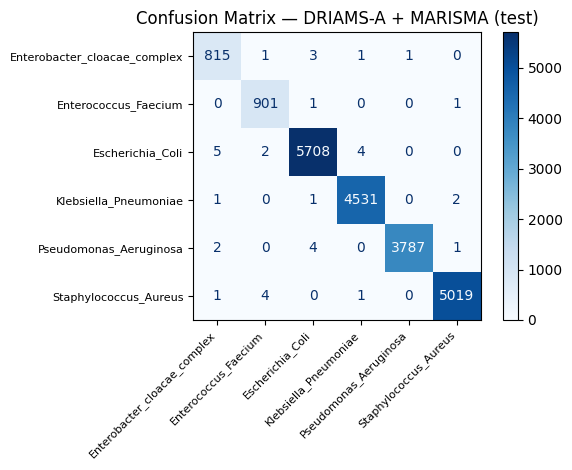


===== Metrics =====
Domain: DRIAMS-D (test)
Balanced Accuracy: 0.9177
F1 Macro: 0.8562
Recall Macro: 0.9177
Specificity Macro: 0.9844



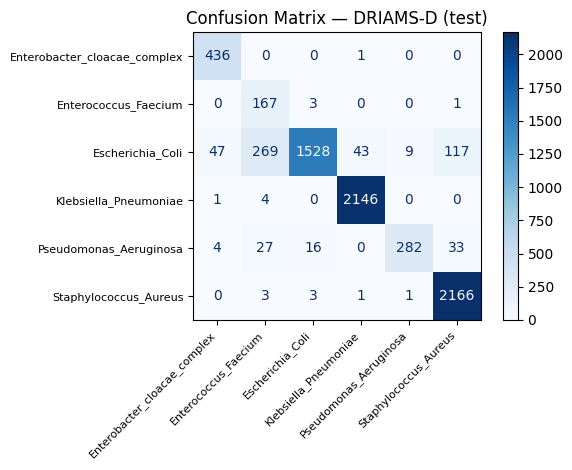

In [47]:
metrics_AM = metrics_report_mlp(
    test_loader_AM, mlp, "DRIAMS-A + MARISMA (test)", class_names=class_names
)
metrics_D = metrics_report_mlp(
    test_loader_D, mlp, "DRIAMS-D (test)", class_names=class_names
)

print_metrics(metrics_AM)
print_metrics(metrics_D)

In [50]:
DOMAIN_MAP = {
    "O": "DRIAMS_A",
    "1": "MARISMA"
}

In [ ]:
from src.models.utils.style_transfer import style_transfer

X_D_TO_A = style_transfer(vae, dataD, 0, device)

In [61]:
Z_D_TO_A = encode_latent(vae, X_D_TO_A, device)

In [62]:
test_loader_DA = make_loader(Z_D_TO_A, y_D)


===== Metrics =====
Domain: DRIAMS-D (test)
Balanced Accuracy: 0.9083
F1 Macro: 0.8368
Recall Macro: 0.9083
Specificity Macro: 0.9814



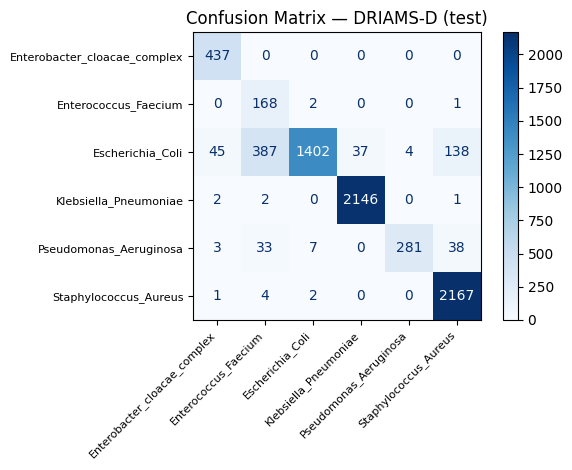

In [63]:
metrics_DA = metrics_report_mlp(
    test_loader_DA, mlp, "DRIAMS-D (test)", class_names=class_names
)

print_metrics(metrics_DA)